In [326]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os

lag = 20 # number of previous time steps to consider
n_features = 15 # number of features
n_steps_out = 1 # number of output steps (how many future steps are we going to predict?)

n_epochs = 60 # 1000 epochs
learning_rate = 0.01 # 0.001 lr

hidden_size = 100 # number of features in hidden state
num_layers = 1 # number of stacked lstm layers

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
data = dataloader(path=path, lag=lag)

2024-04-13 17:55:10.616 | INFO     | utils.DataPreprocessing:load_csv:129 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-04-13 17:55:10.616 | INFO     | utils.DataPreprocessing:load_csv:131 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/HK-Temperature-Forecasting


In [327]:
print(data.train)
print(data.test)

shape: (6_818, 16)
┌───────────┬────────────┬───────────┬──────┬───┬────────────┬────────────┬───────────┬─────────┐
│ AVG_TEMP  ┆ date       ┆ GSR       ┆ SUN  ┆ … ┆ dayofmonth ┆ weekofyear ┆ dayofyear ┆ quarter │
│ ---       ┆ ---        ┆ ---       ┆ ---  ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---     │
│ f32       ┆ date       ┆ f32       ┆ f32  ┆   ┆ f32        ┆ f32        ┆ f32       ┆ f32     │
╞═══════════╪════════════╪═══════════╪══════╪═══╪════════════╪════════════╪═══════════╪═════════╡
│ 29.200001 ┆ 1999-08-01 ┆ 25.1      ┆ 11.6 ┆ … ┆ 1.0        ┆ 30.0       ┆ 213.0     ┆ 3.0     │
│ 29.1      ┆ 1999-08-02 ┆ 15.13     ┆ 7.0  ┆ … ┆ 2.0        ┆ 31.0       ┆ 214.0     ┆ 3.0     │
│ 29.0      ┆ 1999-08-03 ┆ 11.85     ┆ 2.4  ┆ … ┆ 3.0        ┆ 31.0       ┆ 215.0     ┆ 3.0     │
│ 27.5      ┆ 1999-08-04 ┆ 10.67     ┆ 2.3  ┆ … ┆ 4.0        ┆ 31.0       ┆ 216.0     ┆ 3.0     │
│ 27.9      ┆ 1999-08-05 ┆ 15.18     ┆ 6.0  ┆ … ┆ 5.0        ┆ 31.0       ┆ 217.0     ┆ 3.0     │
│

In [328]:
import polars as pl
X_train, y_train = pl.DataFrame(data.train).drop(["date"]), pl.DataFrame(data.train)["AVG_TEMP"].shift(-1)
# remove the last row
X_train = X_train.slice(0, X_train.shape[0] - 1)
y_train = y_train.slice(0, y_train.shape[0] - 1).to_numpy()
print(X_train, y_train)

X_test, y_test = pl.DataFrame(data.test).drop(["date"]), pl.DataFrame(data.test)["AVG_TEMP"].shift(-1)
# remove the last row
X_test = X_test.slice(0, X_test.shape[0] - 1)
y_test = y_test.slice(0, y_test.shape[0] - 1).to_numpy()

shape: (6_817, 15)
┌───────────┬───────────┬──────┬──────┬───┬────────────┬────────────┬───────────┬─────────┐
│ AVG_TEMP  ┆ GSR       ┆ SUN  ┆ RH   ┆ … ┆ dayofmonth ┆ weekofyear ┆ dayofyear ┆ quarter │
│ ---       ┆ ---       ┆ ---  ┆ ---  ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---     │
│ f32       ┆ f32       ┆ f32  ┆ f32  ┆   ┆ f32        ┆ f32        ┆ f32       ┆ f32     │
╞═══════════╪═══════════╪══════╪══════╪═══╪════════════╪════════════╪═══════════╪═════════╡
│ 29.200001 ┆ 25.1      ┆ 11.6 ┆ 79.0 ┆ … ┆ 1.0        ┆ 30.0       ┆ 213.0     ┆ 3.0     │
│ 29.1      ┆ 15.13     ┆ 7.0  ┆ 82.0 ┆ … ┆ 2.0        ┆ 31.0       ┆ 214.0     ┆ 3.0     │
│ 29.0      ┆ 11.85     ┆ 2.4  ┆ 83.0 ┆ … ┆ 3.0        ┆ 31.0       ┆ 215.0     ┆ 3.0     │
│ 27.5      ┆ 10.67     ┆ 2.3  ┆ 87.0 ┆ … ┆ 4.0        ┆ 31.0       ┆ 216.0     ┆ 3.0     │
│ 27.9      ┆ 15.18     ┆ 6.0  ┆ 82.0 ┆ … ┆ 5.0        ┆ 31.0       ┆ 217.0     ┆ 3.0     │
│ …         ┆ …         ┆ …    ┆ …    ┆ … ┆ …          ┆ …   

In [329]:
# turn polar dataframe to pandas dataframe
# X_train = X_train.to_pandas()
# y_train = y_train.to_pandas()
# X_test = X_test.to_pandas()
# y_test = y_test.to_pandas()

In [330]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
mm = MinMaxScaler()
ss = StandardScaler()

X_train_trans, X_test_trans = ss.fit_transform(X_train), ss.fit_transform(X_test)
y_train_trans, y_test_trans = mm.fit_transform(y_train.reshape(-1, 1)), mm.fit_transform(y_test.reshape(-1, 1))

In [331]:
import numpy as np

# split a multivariate sequence past, future samples (X and y)
def split_sequences(input_sequences, output_sequence, n_steps_in, n_steps_out):
    X, y = list(), list() # instantiate X and y
    for i in range(len(input_sequences)):
        # find the end of the input, output sequence
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out - 1
        # check if we are beyond the dataset
        if out_end_ix > len(input_sequences): break
        # gather input and output of the pattern
        seq_x, seq_y = input_sequences[i:end_ix], output_sequence[end_ix-1:out_end_ix, -1]
        X.append(seq_x), y.append(seq_y)
    return np.array(X), np.array(y)

X_train_ss, y_train_mm = split_sequences(X_train_trans, y_train_trans, lag, n_steps_out)
X_test_ss, y_test_mm = split_sequences(X_test_trans, y_test_trans, lag, n_steps_out)
print(X_train_ss.shape, y_train_mm.shape)


(6798, 20, 15) (6798, 1)


In [332]:
assert y_train_mm[0].all() == y_train_trans[lag-1:lag+n_steps_out-1].squeeze(1).all()

In [333]:
import torch
from torch.autograd import Variable

# convert to pytorch tensors
X_train_tensors = Variable(torch.Tensor(X_train_ss))
X_test_tensors = Variable(torch.Tensor(X_test_ss))

y_train_tensors = Variable(torch.Tensor(y_train_mm))
y_test_tensors = Variable(torch.Tensor(y_test_mm))

In [334]:
print(X_train_tensors.shape, y_train_tensors.shape)

torch.Size([6798, 20, 15]) torch.Size([6798, 1])


In [335]:
# reshaping to rows, timestamps, features
X_train_tensors_final = torch.reshape(X_train_tensors,   
                                      (X_train_tensors.shape[0], lag, 
                                       X_train_tensors.shape[2]))
X_test_tensors_final = torch.reshape(X_test_tensors,  
                                     (X_test_tensors.shape[0], lag, 
                                      X_test_tensors.shape[2])) 

print("Training Shape:", X_train_tensors_final.shape, y_train_tensors.shape)
print("Testing Shape:", X_test_tensors_final.shape, y_test_tensors.shape) 

Training Shape: torch.Size([6798, 20, 15]) torch.Size([6798, 1])
Testing Shape: torch.Size([1685, 20, 15]) torch.Size([1685, 1])


In [336]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [337]:
class LSTM(nn.Module):
    
    def __init__(self, num_classes, input_size, hidden_size, num_layers):
        super().__init__()
        self.num_classes = num_classes # output size
        self.num_layers = num_layers # number of recurrent layers in the lstm
        self.input_size = input_size # input size
        self.hidden_size = hidden_size # neurons in each lstm layer
        # LSTM model
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=0.5) # lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) # fully connected 
        self.fc_2 = nn.Linear(128, num_classes) # fully connected last layer
        self.relu = nn.ReLU()
        
    def forward(self,x):
        # hidden state
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        # cell state
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size))
        # propagate input through LSTM
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) # (input, hidden, and internal state)
        hn = hn.view(-1, self.hidden_size) # reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) # first dense
        out = self.relu(out) # relu
        out = self.fc_2(out) # final output
        return out

In [338]:
import warnings
warnings.filterwarnings('ignore')

lstm = LSTM(n_steps_out, 
              n_features, 
              hidden_size, 
              num_layers)
optimiser = torch.optim.Adam(lstm.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, 'min', factor=0.5, patience=3, verbose=True)

training_loss = []
testing_loss = []

In [339]:
def training_loop(n_epochs, lstm, optimiser, loss_fn, scheduler, X_train, y_train,
                  X_test, y_test):
    for epoch in range(n_epochs):
        lstm.train()
        outputs = lstm.forward(X_train) # forward pass
        optimiser.zero_grad() # calculate the gradient, manually setting to 0
        # obtain the loss function
        loss = loss_fn(outputs, y_train)
        loss.backward() # calculates the loss of the loss function
        optimiser.step() # improve from loss, i.e backprop
        # test loss
        lstm.eval()
        test_preds = lstm(X_test)
        test_loss = loss_fn(test_preds, y_test)
        scheduler.step(test_loss)
        lr = optimiser.param_groups[0]['lr']
        # if epoch % 100 == 0:
        print(f"Epoch: {epoch}, train loss: {loss.item():.5f}, test loss: {test_loss.item():.5f}, learning rate: {lr:.5f}")
        training_loss.append(loss.item())
        testing_loss.append(test_loss.item())

training_loop(n_epochs=n_epochs,
              lstm=lstm,
              optimiser=optimiser,
              loss_fn=loss_fn,
              scheduler=scheduler,
              X_train=X_train_tensors_final,
              y_train=y_train_tensors,
              X_test=X_test_tensors_final,
              y_test=y_test_tensors)

Epoch: 0, train loss: 0.51495, test loss: 0.27149, learning rate: 0.01000
Epoch: 1, train loss: 0.22944, test loss: 0.05979, learning rate: 0.01000
Epoch: 2, train loss: 0.05244, test loss: 0.15758, learning rate: 0.01000
Epoch: 3, train loss: 0.18094, test loss: 0.02655, learning rate: 0.01000
Epoch: 4, train loss: 0.02069, test loss: 0.05973, learning rate: 0.01000
Epoch: 5, train loss: 0.04289, test loss: 0.07717, learning rate: 0.01000
Epoch: 6, train loss: 0.05718, test loss: 0.06895, learning rate: 0.01000
Epoch: 7, train loss: 0.05024, test loss: 0.04483, learning rate: 0.00500
Epoch: 8, train loss: 0.03090, test loss: 0.03118, learning rate: 0.00500
Epoch: 9, train loss: 0.02113, test loss: 0.02031, learning rate: 0.00500
Epoch: 10, train loss: 0.01530, test loss: 0.01606, learning rate: 0.00500
Epoch: 11, train loss: 0.01639, test loss: 0.01652, learning rate: 0.00500
Epoch: 12, train loss: 0.02050, test loss: 0.01595, learning rate: 0.00500
Epoch: 13, train loss: 0.02076, tes

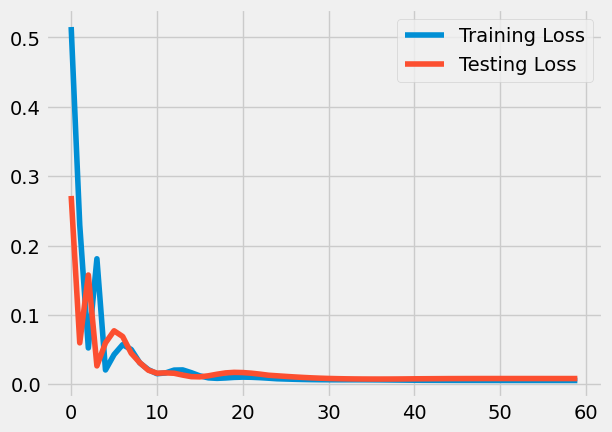

In [340]:
# plot the loss function
import matplotlib.pyplot as plt
plt.plot(training_loss, label="Training Loss")
plt.plot(testing_loss, label="Testing Loss")
plt.legend()
plt.savefig("loss.png")


In [341]:
# make predictions
test_predict = lstm(X_test_tensors_final)
data_predict = test_predict.data.numpy() # numpy conversion
data_predict = mm.inverse_transform(data_predict) # reverse transformation
dataY_plot = mm.inverse_transform(y_test_mm) # reverse transformation

print(test_predict.shape)

torch.Size([1685, 1])


In [342]:
print(y_test_tensors.shape)

torch.Size([1685, 1])


In [343]:
print(data_predict[:, 0])

[21.201077 23.128376 24.758728 ... 22.900015 24.662085 25.09898 ]


In [344]:
print(dataY_plot.shape, data_predict.shape)


(1685, 1) (1685, 1)


In [345]:
print(len(dataY_plot[0, :]))
print(len(data_predict[0, :]))

1
1


In [346]:
# get the r2 score, mean squared error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(dataY_plot[:, -1], data_predict[:, -1])
mse = mean_squared_error(dataY_plot[:, -1], data_predict[:, -1])
mae = mean_absolute_error(dataY_plot[:, -1], data_predict[:, -1])

print("R2 Score: %1.5f" % r2)
print("Mean Squared Error: %1.5f" % mse)
print("Mean Absolute Error: %1.5f" % mae)


R2 Score: 0.79227
Mean Squared Error: 4.60052
Mean Absolute Error: 1.72186


In [347]:
# get the r2 score, mean squared error
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(dataY_plot, data_predict)
mse = mean_squared_error(dataY_plot, data_predict)
mae = mean_absolute_error(dataY_plot, data_predict)

print("R2 Score: %1.5f" % r2)
print("Mean Squared Error: %1.5f" % mse)
print("Mean Absolute Error: %1.5f" % mae)


R2 Score: 0.79227
Mean Squared Error: 4.60052
Mean Absolute Error: 1.72186


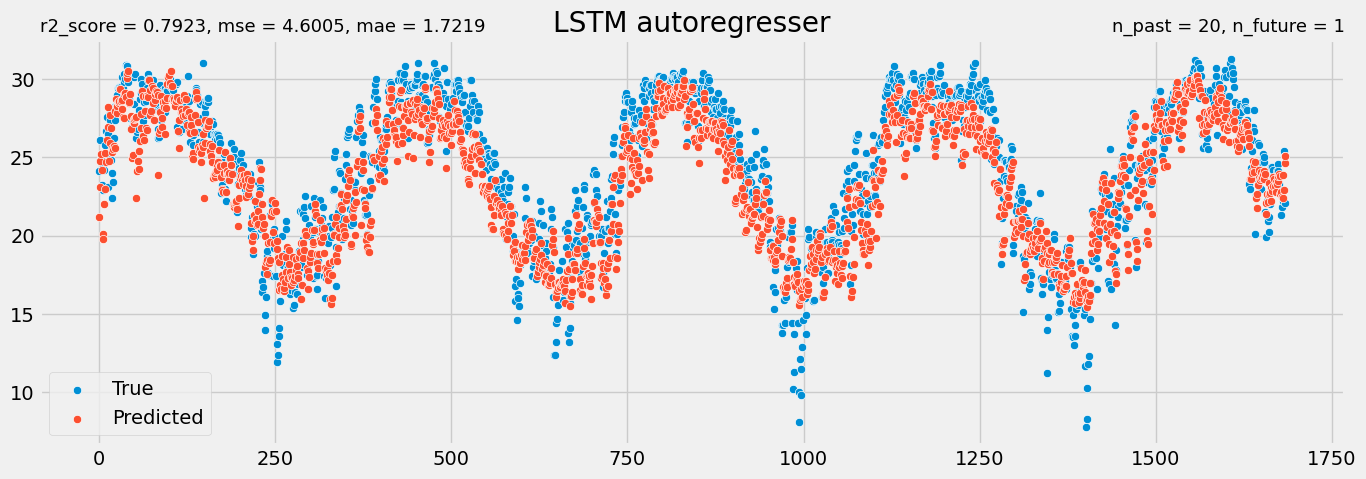

In [348]:
import seaborn as sns
import matplotlib.pyplot as plt

x_values = np.arange(test_predict.shape[0])
# x_values = np.arange(n_steps_out)
fig, ax = plt.subplots(
    figsize=(15, 5),
)

plt.title("LSTM autoregresser")
plt.title(f"n_past = {lag:}, n_future = {n_steps_out}", loc="right", fontsize=13)
plt.title(f"r2_score = {r2:1.4f}, mse = {mse:1.4f}, mae = {mae:1.4f}", loc="left", fontsize=13)

sns.scatterplot(x=x_values, y=dataY_plot[:, -1], ax=ax, label="True")
sns.scatterplot(x=x_values, y=data_predict[:, -1], ax=ax, label="Predicted")

# sns.scatterplot(x=x_values, y=dataY_plot[-1, :], ax=ax, label="True")
# sns.scatterplot(x=x_values, y=data_predict[-1, :], ax=ax, label="Predicted")

# plt.plot(dataY_plot[-1, :], label="True")
# plt.plot(data_predict[-1, :], label="Predicted")

plt.savefig("lstm.png")